# Interactive Script 

In [1]:
!which python

/dss/dsshome1/08/di38red/micromamba/envs/arosics/bin/python


In [1]:
import arosics

In [3]:
import stac2ardcube

In [4]:
stac2ardcube.get_stac_layers

<function stac2ardcube.main.get_stac_layers(mission, polygon, resolution=None, daterange=None, bands=None, max_cc=None, clip_raster=None, cloud_masking=None, indices=None, output=None, aggregator=None, topographic_features=None, animation=None)>

In [5]:
stac2ardcube.get_stac_layers

<function stac2ardcube.main.get_stac_layers(mission, polygon, resolution=None, daterange=None, bands=None, max_cc=None, clip_raster=None, cloud_masking=None, indices=None, output=None, aggregator=None, topographic_features=None, animation=None)>

In [5]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt 
import rioxarray
import rasterio as rio
from terrabyte_cube.main import mainfunc
from pystac_client import Client as pystacclient
from odc.stac import stac_load
import geopandas as gpd
import rasterio
from terrabyte_cube.export_cfg import export_stac

In [6]:
ds_stac = xr.open_dataset("/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/masking_test_stac_masked.nc")
da_stac = ds_stac.Spectral_Temporal_Stack

In [8]:
ds_stac

<xarray.Dataset> Size: 173MB
Dimensions:                  (y: 470, x: 1277, time: 6, band: 6)
Coordinates:
  * y                        (y) float64 4kB 4.583e+06 4.583e+06 ... 4.578e+06
  * x                        (x) float64 10kB 5.344e+05 5.344e+05 ... 5.471e+05
  * time                     (time) datetime64[ns] 48B 2024-04-04T05:57:37.07...
  * band                     (band) <U5 120B 'blue' 'green' ... 'ndvi' 'ndwi'
Data variables:
    spatial_ref              int64 8B ...
    Spectral_Temporal_Stack  (time, band, y, x) float64 173MB ...

In [3]:
from terrabyte_cube.get_animation import generate_animation

MovieWriter imagemagick unavailable; using Pillow instead.


Number of images: 6


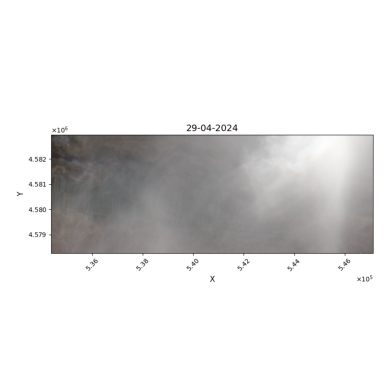

In [5]:
generate_animation(da_stac)

In [10]:
!which python

/dss/dsstbyfs01/pn56su/pn56su-dss-0020/opt/miniconda3/23.3.1/bin/python


In [1]:
from terrabyte_cube.raincloud_plot import generate_raincloud_plots

Saved plot: /dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/graphs/orog_1/ndvi_mean.png
Saved plot: /dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/graphs/orog_1/ndvi_median.png
Saved plot: /dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/graphs/orog_1/ndvi_std.png
Saved plot: /dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/graphs/orog_1/ndwi_mean.png
Saved plot: /dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/graphs/orog_1/ndwi_median.png
Saved plot: /dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/graphs/orog_1/ndwi_std.png


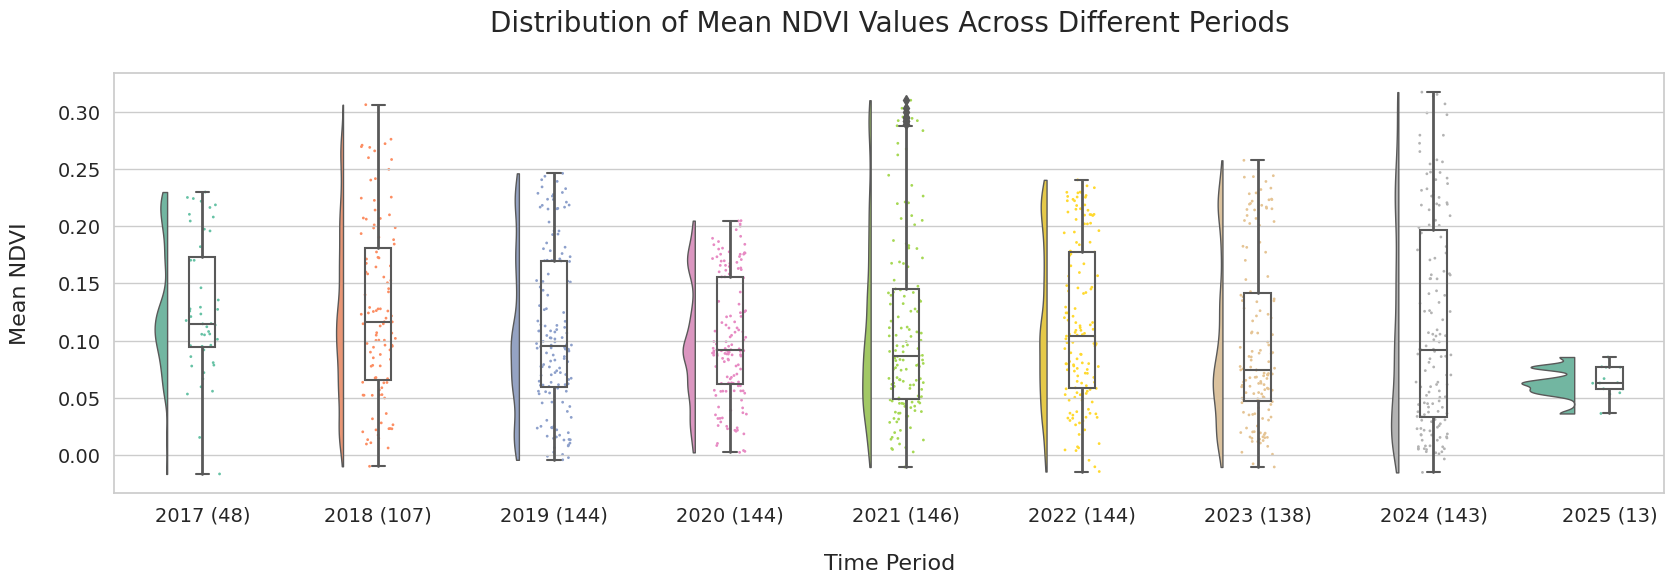

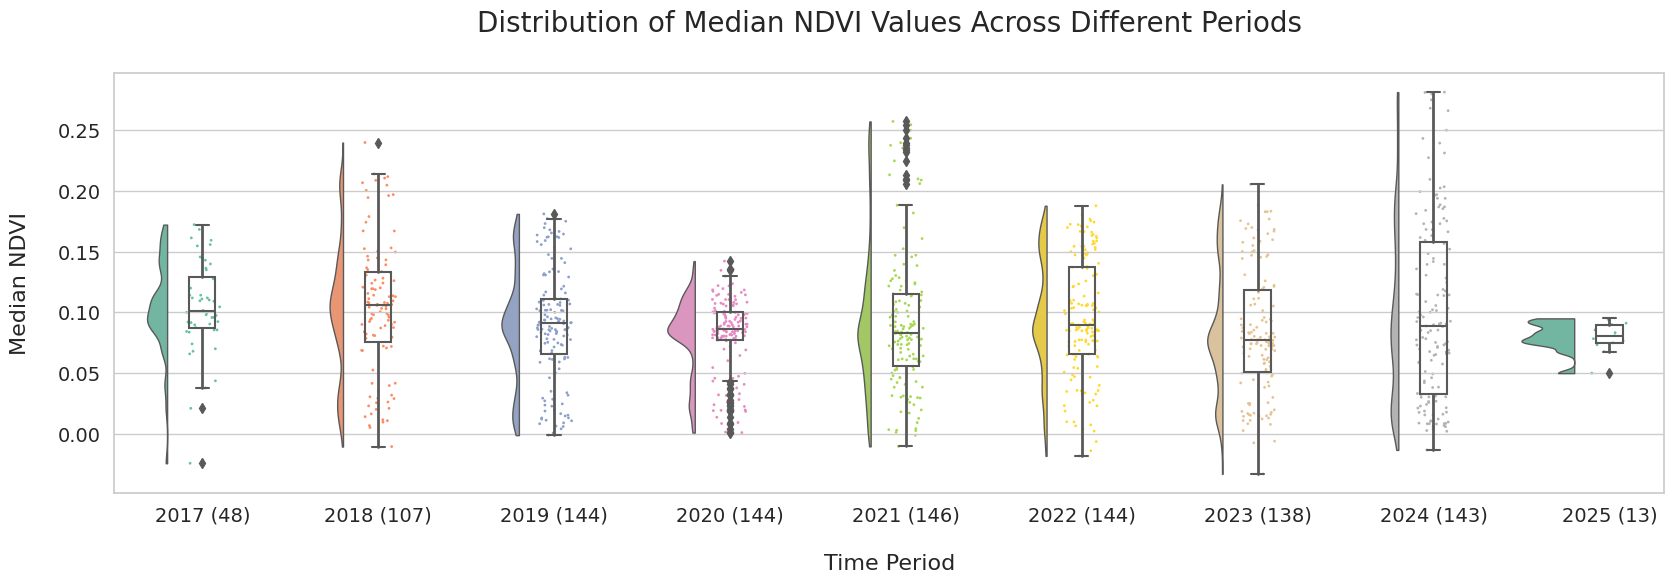

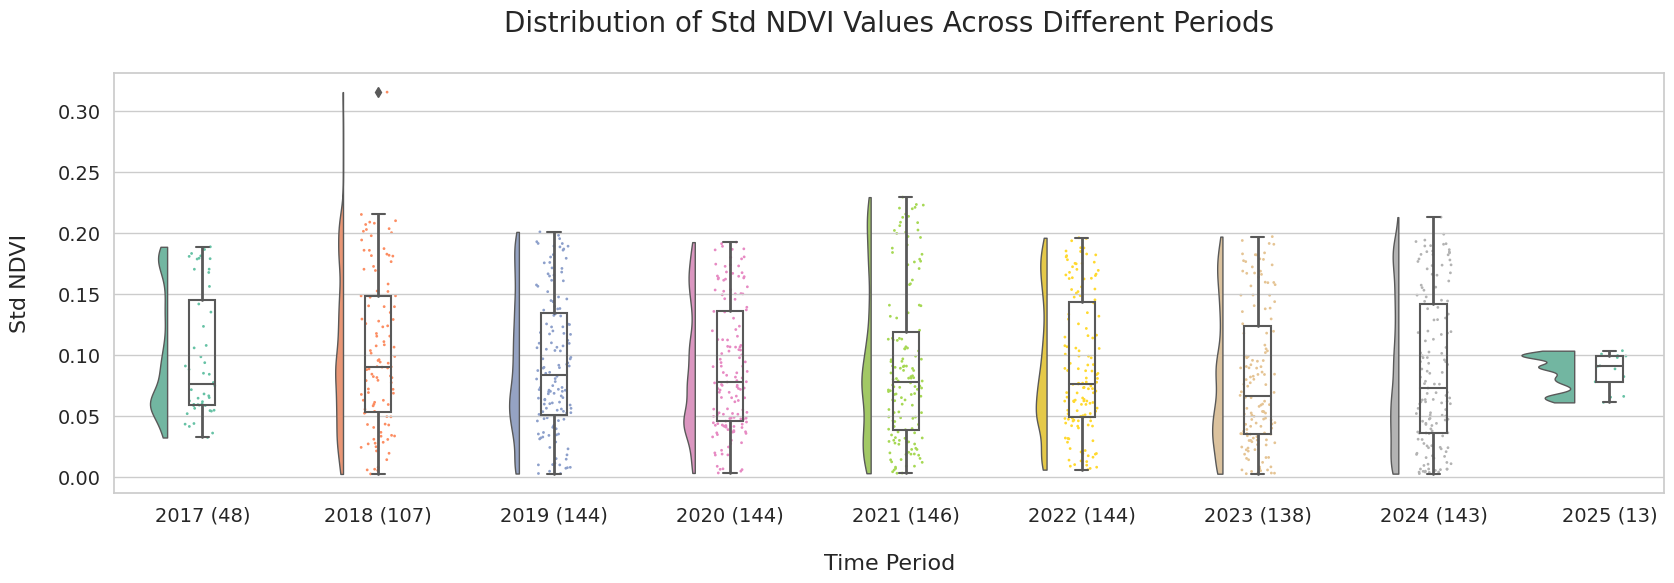

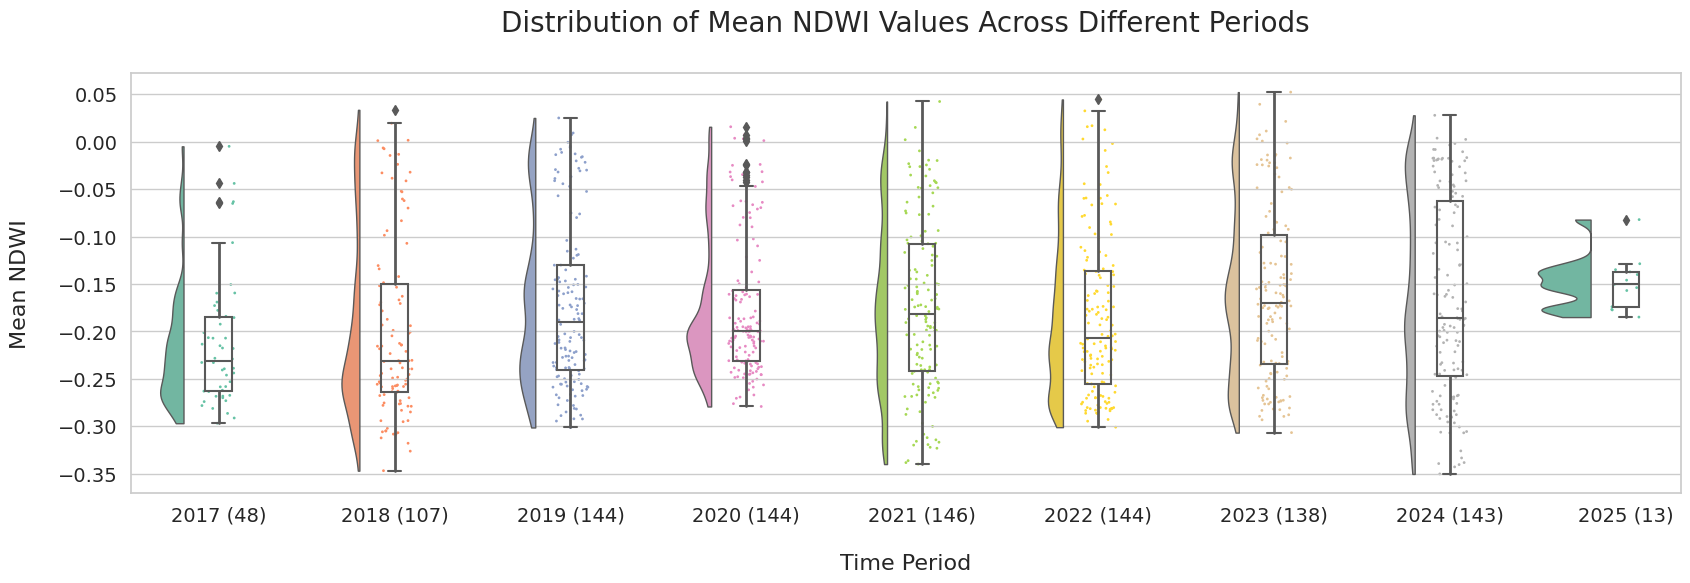

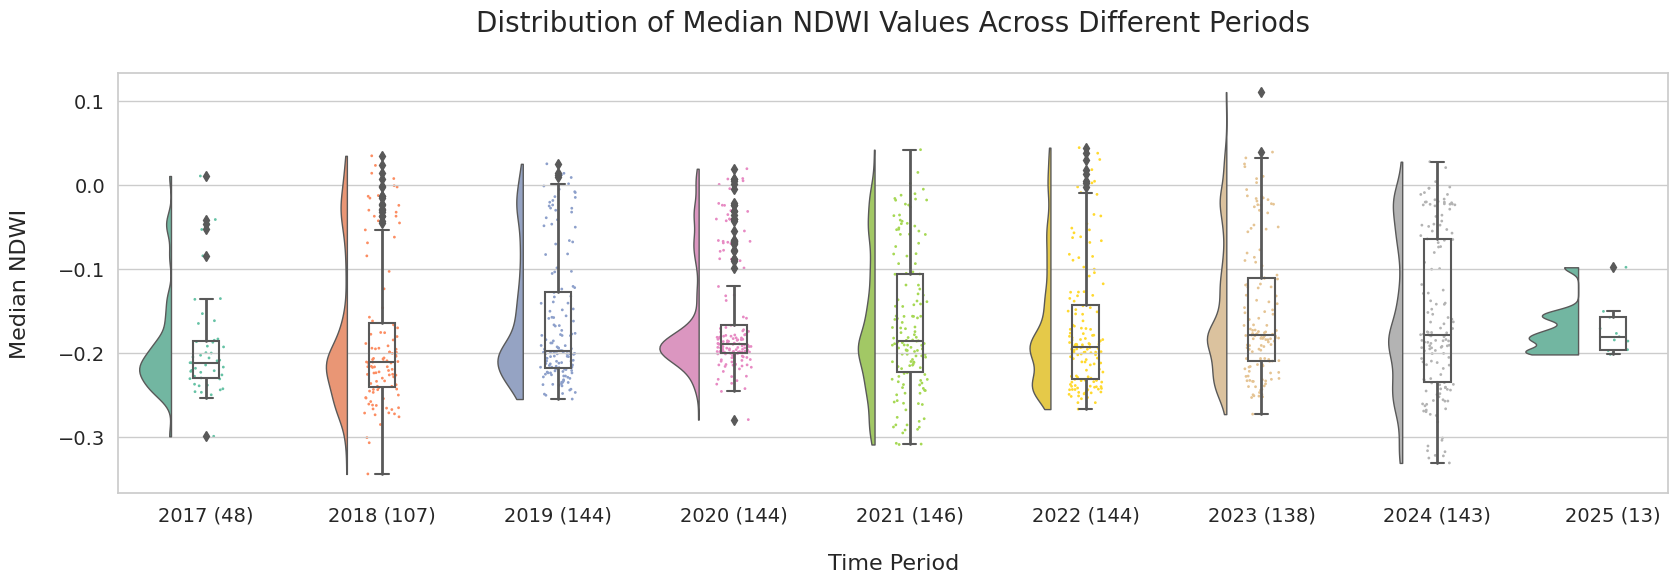

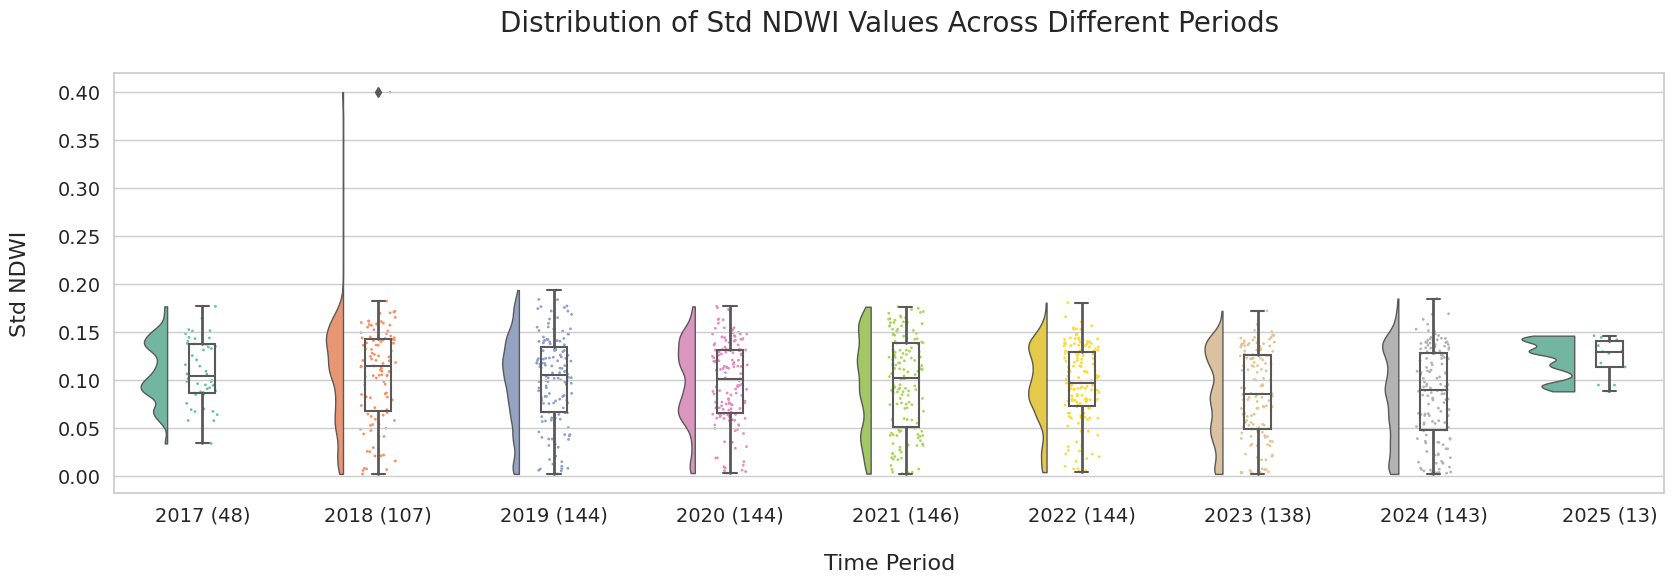

In [2]:
generate_raincloud_plots(input_path="/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/orog_1_cc100.nc", output_dir="/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/graphs/orog_1/", bands=["ndvi","ndwi"], stats=['mean', 'median', 'std'])

### Tile extraction

In [36]:
catalog_url = 'https://earth-search.aws.element84.com/v1/'
catalog = pystacclient.open(catalog_url)

bbox_list= [100.767417,45.208589,100.783210,45.215543]
collection = 'sentinel-2-l1c'
bbox = bbox_list
start = '2020-08-29'
end = '2020-08-29'
results = catalog.search(
    bbox = bbox,
    collections=[collection],
    datetime=[start, end]
)
items = results.item_collection() #item_collection
print("%s items found" % len(items))

1 items found


In [37]:
items[0]

<Item id=S2A_21XVJ_20200829_2_L1C>

In [31]:
stac_json = items
gdf = gpd.GeoDataFrame.from_features(stac_json, "epsg:4326")

In [32]:
gdf

,geometry,created,platform,constellation,instruments,eo:cloud_cover,proj:epsg,mgrs:utm_zone,mgrs:latitude_band,mgrs:grid_square,...,s2:datatake_type,s2:datastrip_id,s2:granule_id,s2:reflectance_conversion_factor,datetime,s2:sequence,earthsearch:s3_path,earthsearch:payload_id,processing:software,updated
0,"POLYGON ((-180 90, -180 -90, 180 -90, 180 90, ...",2024-03-02T12:32:08.668Z,sentinel-2a,sentinel-2,[msi],0.8059,32623,23,X,MJ,...,INS-NOBS,S2A_OPER_MSI_L1C_DS_MPS__20180904T225053_S2018...,S2A_OPER_MSI_L1C_TL_MPS__20180904T225053_A0167...,0.982174,2018-09-04T19:29:10.455000Z,2,s3://earthsearch-data/sentinel-2-l1c/23/X/MJ/2...,roda-sentinel2/workflow-sentinel2-to-stac/5b76...,{'sentinel2-to-stac': '0.1.1'},2024-03-02T12:32:08.668Z


In [11]:
gdf = gpd.GeoDataFrame.from_features(stac_json, "epsg:4326")

# Compute granule id from components
gdf["granule"] = (
    gdf["mgrs:utm_zone"].apply(lambda x: f"{x:02d}")
    + gdf["mgrs:latitude_band"]
    + gdf["mgrs:grid_square"]
)

In [18]:
unique_values = gdf["granule"].unique()
unique_values

array(['47TPL'], dtype=object)

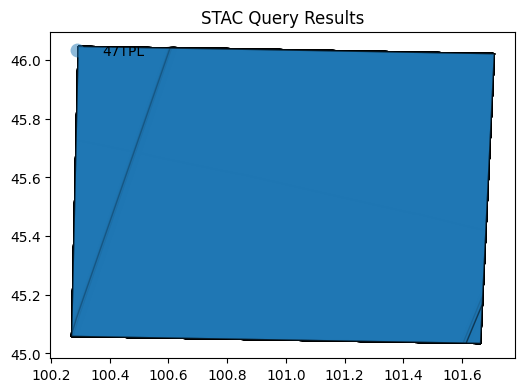

In [13]:
fig = gdf.plot(
    "granule",
    edgecolor="black",
    categorical=True,
    aspect="equal",
    alpha=0.5,
    figsize=(6, 12),
    legend=True,
    legend_kwds={"loc": "upper left", "frameon": False, "ncol": 1},
)
_ = fig.set_title("STAC Query Results")

### Mask stac with cloud layers

In [2]:
from terrabyte_cube.cloud_masking import mask_stac_clouds

In [3]:
mask_stac_clouds("/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/masking_test_stac.nc", "/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/masking_test_cloud.nc", "/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/test666.nc")

Export is done: /dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/test666.nc


In [8]:
mask_stac_clouds(da_stac, da_cloud, "/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/maskedtest4.nc")

Export is done: /dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/maskedtest4.nc


In [13]:
def process_input(data):
    if isinstance(data, xr.DataArray):
        print("Input is a DataArray")
    elif isinstance(data, xr.Dataset):
        print("Input is a Dataset")
    else:
        print("Unsupported type. Please provide an xarray DataArray or Dataset.")
        
process_input(da_stac)

Input is a DataArray


In [2]:
ds_stac = xr.open_dataset("/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/naryn_terrabyteshowcase.nc")
ds_cloud = xr.open_dataset("/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/naryn_cloud_terrabyteshowcase4.nc")
#ds_cloud = xr.open_dataset("/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/orog_1_cloud_new.nc")
da_stac = ds_stac.Spectral_Temporal_Stack
da_cloud = ds_cloud.Cloud_Stack

In [32]:
crs = ds_cloud.spatial_ref.crs_wkt

In [37]:
transform = ds_cloud.rio.transform()

In [3]:
cloud_prob = da_cloud.sel(band="cloud_prob")

In [4]:
prob = cloud_prob[0]

In [5]:
prob

<xarray.DataArray 'Cloud_Stack' (y: 470, x: 1277)> Size: 2MB
[600190 values with dtype=float32]
Coordinates:
    time     datetime64[ns] 8B 2024-04-04T05:57:37.074000
  * y        (y) float64 4kB 4.583e+06 4.583e+06 ... 4.578e+06 4.578e+06
  * x        (x) float64 10kB 5.344e+05 5.344e+05 ... 5.471e+05 5.471e+05
    band     <U10 40B 'cloud_prob'
Attributes:
    grid_mapping:  spatial_ref

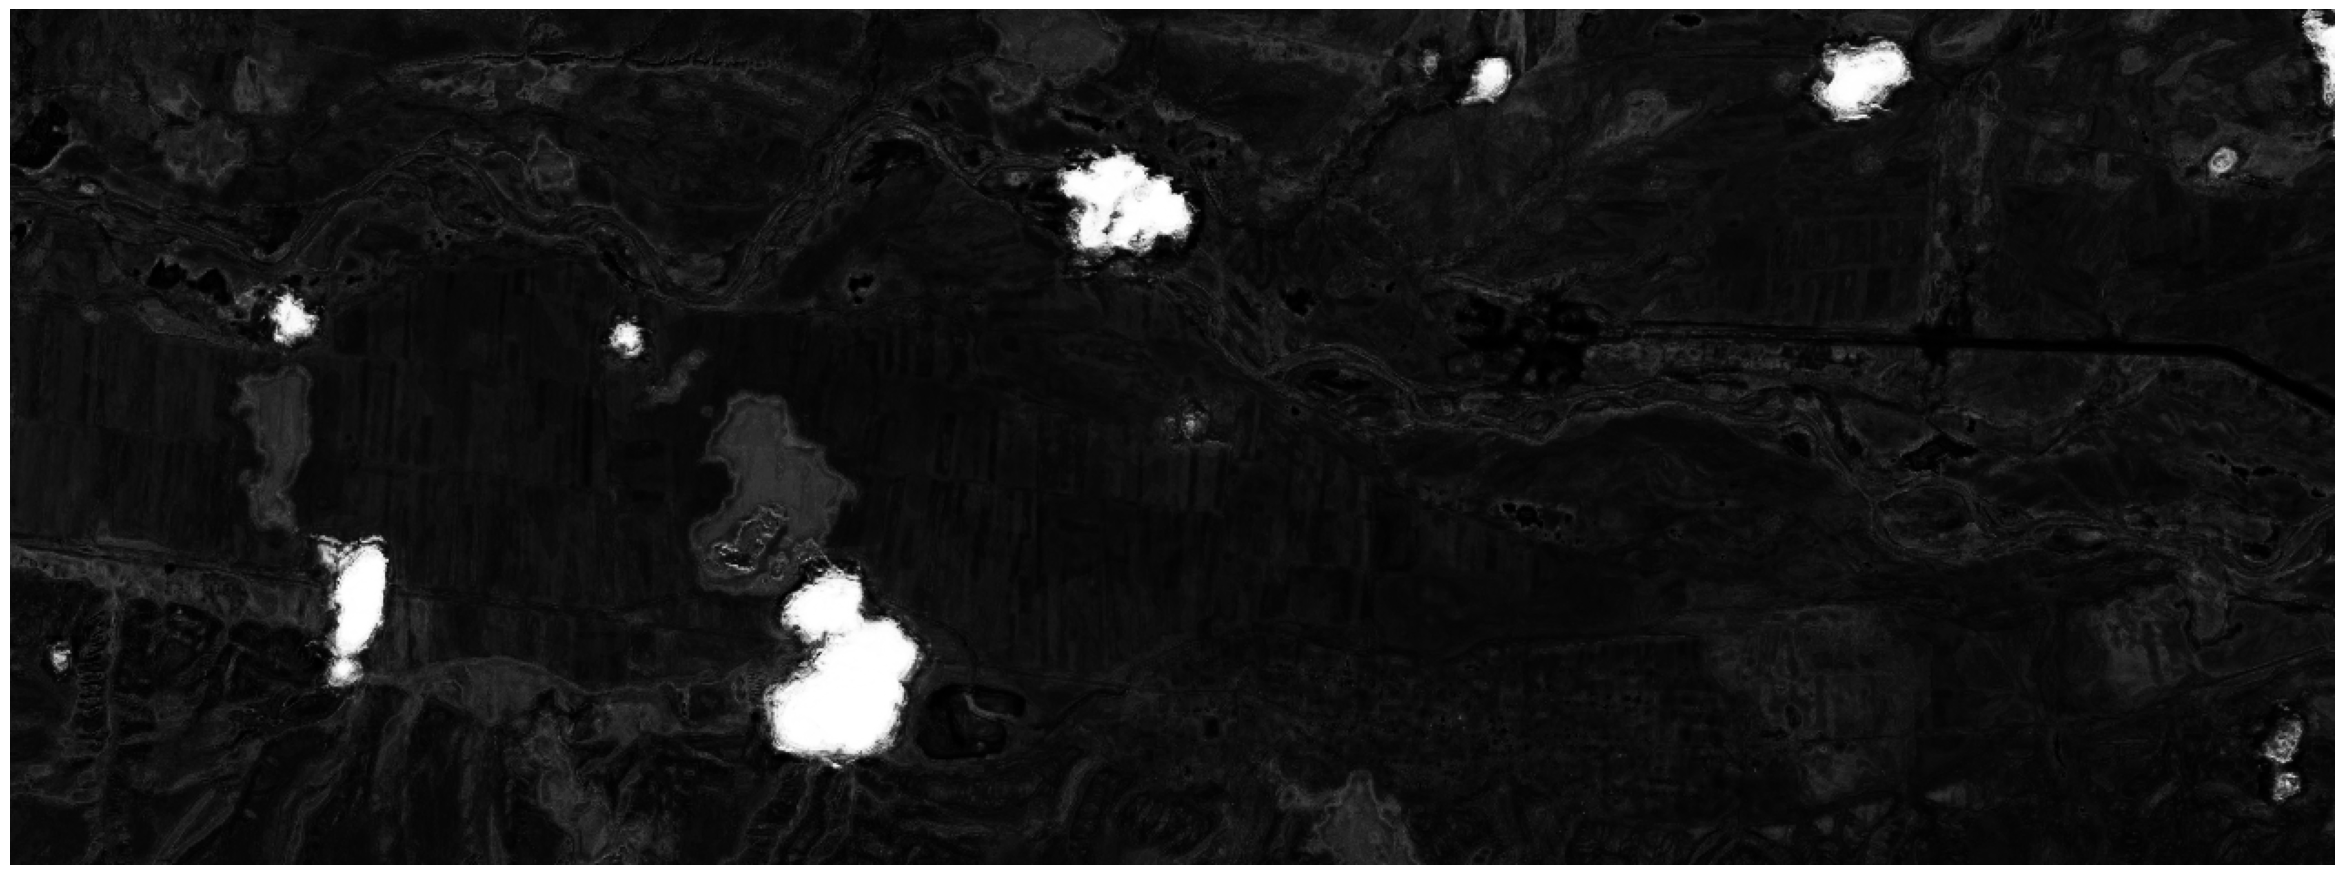

In [7]:
fig, ax = plt.subplots(figsize=(30, 20))
ax.axis('off')
ax.imshow(prob, cmap='gray')

In [42]:
smoothed_prob.rio.write_crs(crs, inplace=True)

<xarray.DataArray (y: 470, x: 1277)> Size: 2MB
array([[0.04887319, 0.05046241, 0.05611867, ..., 0.05850858, 0.08153769,
        0.10361417],
       [0.05175386, 0.05408279, 0.05848785, ..., 0.05953532, 0.08256673,
        0.1011743 ],
       [0.05846219, 0.0609954 , 0.06281088, ..., 0.05606518, 0.06877961,
        0.07781607],
       ...,
       [0.04525591, 0.04535555, 0.04767389, ..., 0.04536407, 0.04216849,
        0.03841409],
       [0.04617651, 0.0470213 , 0.05049176, ..., 0.04584354, 0.04419324,
        0.04213244],
       [0.04445398, 0.04702942, 0.05186883, ..., 0.04234117, 0.03996801,
        0.03838606]], dtype=float32)
Coordinates:
    time         datetime64[ns] 8B 2024-04-04T05:57:37.074000
  * y            (y) float64 4kB 4.583e+06 4.583e+06 ... 4.578e+06 4.578e+06
  * x            (x) float64 10kB 5.344e+05 5.344e+05 ... 5.471e+05 5.471e+05
    band         <U10 40B 'cloud_prob'
    spatial_ref  int64 8B 0

In [43]:
smoothed_prob.rio.write_transform(transform, inplace=True)

<xarray.DataArray (y: 470, x: 1277)> Size: 2MB
array([[0.04887319, 0.05046241, 0.05611867, ..., 0.05850858, 0.08153769,
        0.10361417],
       [0.05175386, 0.05408279, 0.05848785, ..., 0.05953532, 0.08256673,
        0.1011743 ],
       [0.05846219, 0.0609954 , 0.06281088, ..., 0.05606518, 0.06877961,
        0.07781607],
       ...,
       [0.04525591, 0.04535555, 0.04767389, ..., 0.04536407, 0.04216849,
        0.03841409],
       [0.04617651, 0.0470213 , 0.05049176, ..., 0.04584354, 0.04419324,
        0.04213244],
       [0.04445398, 0.04702942, 0.05186883, ..., 0.04234117, 0.03996801,
        0.03838606]], dtype=float32)
Coordinates:
    time         datetime64[ns] 8B 2024-04-04T05:57:37.074000
  * y            (y) float64 4kB 4.583e+06 4.583e+06 ... 4.578e+06 4.578e+06
  * x            (x) float64 10kB 5.344e+05 5.344e+05 ... 5.471e+05 5.471e+05
    band         <U10 40B 'cloud_prob'
    spatial_ref  int64 8B 0

In [44]:
smoothed_prob.to_netcdf("/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/smoothedmask3.nc")

In [17]:
masking = "/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/naryn_latest_stac.nc"

In [20]:
import os
masking = "/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/naryn_latest_stac.nc"

# Split the path into directory, filename, and extension.
dirname, filename = os.path.split(masking)
name, ext = os.path.splitext(filename)

# Create the new filename by appending '_masked' before the extension.
output_filename = f"{name}_masked{ext}"
output_mask = os.path.join(dirname, output_filename)

print(output_mask)

/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/naryn_latest_stac_masked.nc


In [9]:
ds_stac

<xarray.Dataset> Size: 259MB
Dimensions:                  (y: 470, x: 1277, time: 9, band: 6)
Coordinates:
  * y                        (y) float64 4kB 4.583e+06 4.583e+06 ... 4.578e+06
  * x                        (x) float64 10kB 5.344e+05 5.344e+05 ... 5.471e+05
  * time                     (time) datetime64[ns] 72B 2022-01-05T05:57:35.20...
  * band                     (band) <U5 120B 'blue' 'green' ... 'ndvi' 'ndwi'
Data variables:
    spatial_ref              int64 8B ...
    Spectral_Temporal_Stack  (time, band, y, x) float64 259MB ...

In [14]:
list(ds_stac.data_vars)[1]

'Spectral_Temporal_Stack'

In [3]:
stac = da_stac
cloud = da_cloud

"""
if isinstance(stac, xr.Dataset):
    stac = stac.Spectral_Temporal_Stack
if isinstance(cloud, xr.Dataset):
    cloud = cloud.Cloud_Stack
"""


print(cloud)
cloud_mask = cloud.sel(band='cloud_mask')
masked_stac = stac.where(cloud_mask == 0)

<xarray.DataArray 'Cloud_Stack' (time: 9, band: 2, y: 470, x: 1277)> Size: 43MB
[10803420 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 72B 2022-01-05T05:57:35.206000 ... 2022-02...
  * y        (y) float64 4kB 4.583e+06 4.583e+06 ... 4.578e+06 4.578e+06
  * x        (x) float64 10kB 5.344e+05 5.344e+05 ... 5.471e+05 5.471e+05
  * band     (band) <U10 80B 'cloud_prob' 'cloud_mask'
Attributes:
    grid_mapping:  spatial_ref


In [17]:
da_stac.attrs['transform'] = da_stac.rio.transform()

In [4]:
da_cloud

<xarray.DataArray 'Cloud_Stack' (time: 9, band: 2, y: 470, x: 1277)> Size: 43MB
[10803420 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 72B 2022-01-05T05:57:35.206000 ... 2022-02...
  * y        (y) float64 4kB 4.583e+06 4.583e+06 ... 4.578e+06 4.578e+06
  * x        (x) float64 10kB 5.344e+05 5.344e+05 ... 5.471e+05 5.471e+05
  * band     (band) <U10 80B 'cloud_prob' 'cloud_mask'
Attributes:
    grid_mapping:  spatial_ref

import datetime
dates_stac = da_stac.time.values.astype('datetime64[D]')
dates_cloud = da_cloud.time.values.astype('datetime64[D]')

len(dates_stac)
len(dates_cloud)

dif = np.setdiff1d(dates_cloud, dates_stac)
#dif = np.setdiff1d(dates_stac, dates_cloud)

dif

len(dif)

In [5]:
cloud_mask = da_cloud.sel(band='cloud_mask')

In [6]:
masked_stac = da_stac.where(cloud_mask == 0)

In [7]:
export_stac(masked_stac, "/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/masked_naryn4.nc")

Export is done and the process is concluded successfully!


In [96]:
masked_stac.to_netcdf("/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/masked_naryn.nc")

In [100]:
masked_stac.crs

'PROJCRS["WGS 84 / UTM zone 43N",BASEGEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],MEMBER["World Geodetic System 1984 (G2139)"],MEMBER["World Geodetic System 1984 (G2296)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[2.0]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4326]],CONVERSION["UTM zone 43N",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",75,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natural origin",0.9996,SCALEUNIT["unity",1],ID["EPSG",8805]],PARAMETER["False e

In [102]:
masked_stac

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 9, band: 6, y: 470, x: 1277)> Size: 259MB
array([[[[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         ...,
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan]],

        [[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
...
         [-8.35496814e-03, -1.70182508e-02, -9.92670934e-03, ...,
          -4.46452536e-02, -7.43677375e-02, -4.95012469e-02],
         [-7.54345687e-03, -1.03928788e-02, -5.69313977e-03, ...,
          -3.86563583e-02, -4.85369252e-02, -3.88415673e-03],
         [-1.62231720e-02, -1.21748506e-02, -1.56324469e-02, ...,
          -2.20144753e-02, -3.35577213e-02, -7.57038088e-03]],

        [[-3.54588343e-02,  1.17359745e-02,  2.97382199e-02, ...,
           4.16688644e-03, -5.80567422e-03,  2.68658320e-04],
         [-3.87176326e-02, -4.74642393e-02, -3.60828411e-02, ...,
           1.57807309e-02,  5.65580393e-03,  2.24478888e-03],
         [ 4.02504472e-03, -6.24277457e-03, -1.38786236e-02, ...,
           0.00000000e+00,  7.60112688e-03,  3.74772460e-03],
         ...,
         [-4.76031799e-05,  1.02620400e-02,  3.78063011e-03, ...,
           5.20241477e-02,  6.06270810e-02,  1.52435086e-02],
         [ 2.30794593e-03,  7.75700935e-03,  3.09185178e-03, ...,
           4.11487070e-02,  3.83757775e-02, -1.27476791e-02],
         [ 1.03559871e-02,  6.82054293e-03,  1.45992366e-02, ...,
           1.90068062e-02,  1.97696933e-02, -5.74741618e-02]]]])
Coordinates:
  * y        (y) float64 4kB 4.583e+06 4.583e+06 ... 4.578e+06 4.578e+06
  * x        (x) float64 10kB 5.344e+05 5.344e+05 ... 5.471e+05 5.471e+05
  * time     (time) datetime64[ns] 72B 2022-01-05T05:57:35.206000 ... 2022-02...
  * band     (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
Attributes:
    crs:           PROJCRS["WGS 84 / UTM zone 43N",BASEGEOGCRS["WGS 84",ENSEM...
    grid_mapping:  spatial_ref

masked_stac.rio.write_crs(masked_stac.crs)

## Read a netcdf file and create single geotif image of mean

In [72]:
ds = xr.open_dataset("/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/orog_1_noclip.nc")
da = ds.Spectral_Temporal_Stack

In [76]:
ds.to_netcdf("/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/crs_test9.nc")

In [91]:
band = "ndvi"
ds = xr.open_dataset("/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/orog_1_noclip.nc")
da = ds.Spectral_Temporal_Stack
da_sel = da.sel(band=band)
da_sel = da_sel.mean(dim="time")
crs = ds.spatial_ref.crs_wkt
da_sel = da_sel.rio.write_crs(crs)
da_sel.rio.to_raster("/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/orog_1_ndvi_mean.tif")

### For RGB

In [95]:
# Open the dataset
ds = xr.open_dataset("/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/orog_1_noclip.nc")
da = ds.Spectral_Temporal_Stack

# Select the RGB bands (adjust these names if your dataset uses different labels)
da_sel = da.sel(band=["red", "green", "blue"])

# Compute the mean across the time dimension
da_sel = da_sel.median(dim="time")

# Get the coordinate reference system and assign it
crs = ds.spatial_ref.crs_wkt
da_sel = da_sel.rio.write_crs(crs)

# Write the output raster (a 3-band GeoTIFF)
output_path = "/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/orog_1_rgb_median.tif"
da_sel.rio.to_raster(output_path)

# Reopen the file with rasterio to add band descriptions (so QGIS shows band names)
with rasterio.open(output_path, "r+") as dst:
    dst.descriptions = ("red", "green", "blue")

### Make time series

In [97]:
ds = xr.open_dataset("/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/orog_1_noclip.nc")
da = ds.Spectral_Temporal_Stack

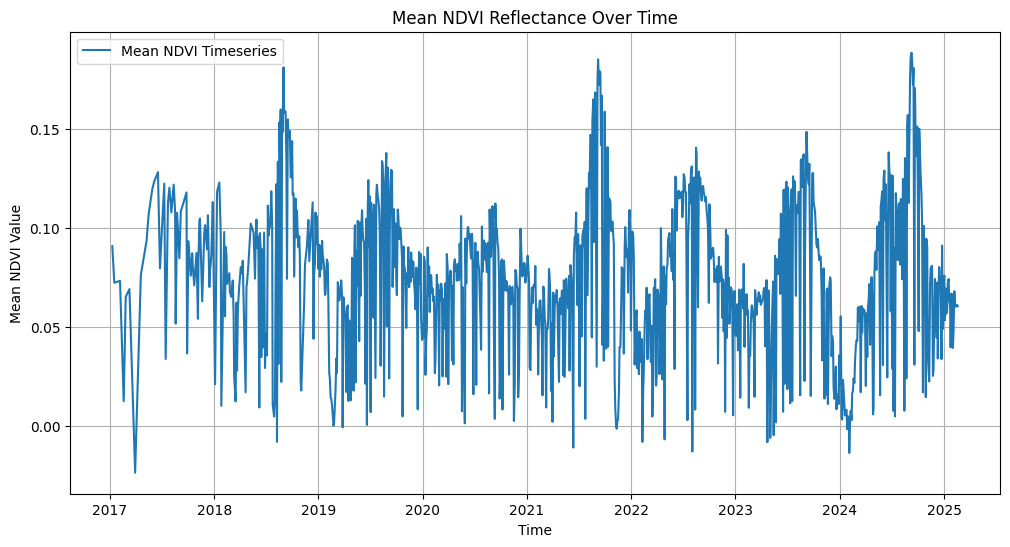

In [98]:
band = "ndvi"
da_sel = da.sel(band=band)
da_sel = da_sel.mean(dim=["x", "y"])

# Plot the values over time
plt.figure(figsize=(12, 6))
plt.plot(da_sel["time"], da_sel, label="Mean NDVI Timeseries")
plt.xlabel("Time")
plt.ylabel("Mean NDVI Value")
plt.title("Mean NDVI Reflectance Over Time")
plt.legend()
plt.grid()
plt.show()

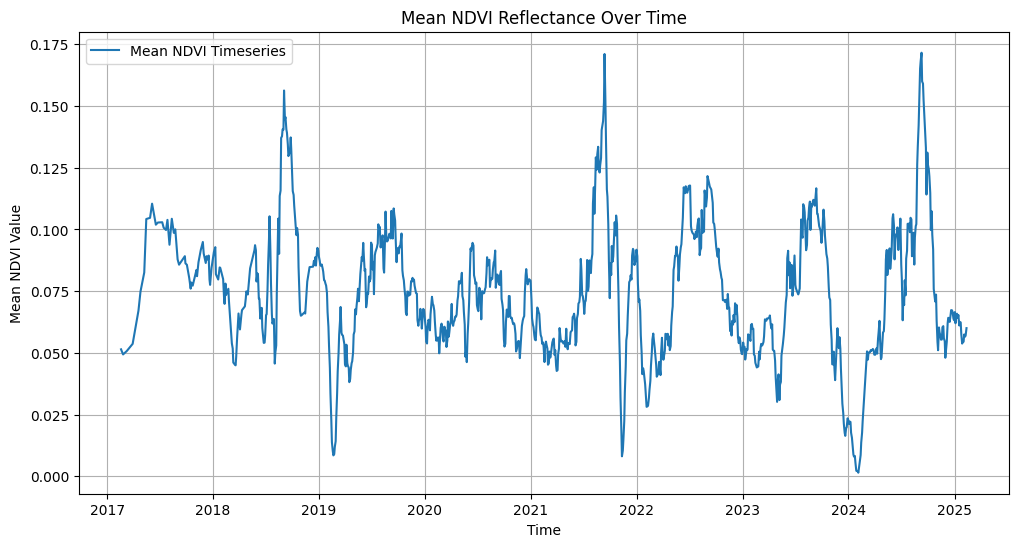

In [103]:
smoothed_da = da_sel.rolling(time=7, center=True).mean()
plt.figure(figsize=(12, 6))
plt.plot(smoothed_da["time"], smoothed_da, label="Mean NDVI Timeseries")
plt.xlabel("Time")
plt.ylabel("Mean NDVI Value")
plt.title("Mean NDVI Reflectance Over Time")
plt.legend()
plt.grid()
plt.show()

### Export timeseries as .csv

In [106]:
# Compute the mean for both bands over x and y dimensions
da_ndvi = da.sel(band="ndvi").median(dim=["x", "y"])
da_ndwi = da.sel(band="ndwi").median(dim=["x", "y"])

# Convert each to a DataFrame
df_ndvi = da_ndvi.to_dataframe(name="mean_value").reset_index()
df_ndvi["band"] = "ndvi"

df_ndwi = da_ndwi.to_dataframe(name="mean_value").reset_index()
df_ndwi["band"] = "ndwi"

# Combine the two DataFrames into one
df_all = pd.concat([df_ndvi, df_ndwi], ignore_index=True)

# Optionally, sort the DataFrame by time and band
df_all = df_all.sort_values(by=["time", "band"])

# Export the combined DataFrame to CSV
df_all.to_csv("median_timeseries.csv", index=False)


### Group by year

In [ ]:
import xarray as xr

# Assuming 'da' is your xarray DataArray and the band dimension represents spectral bands
nir_band = da.sel(band="nir")  # Select the NIR band (adjust the index if needed)

# Add a year dimension if time has a date-related component (adjust based on your time format)
# For example, if 'time' is a datetime array, you can extract the year
nir_band['year'] = nir_band.time.dt.year

# Compute the mean for each year
mean_nir_per_year = nir_band.groupby('year').mean()

# Loop over the years and print the mean values
for year in mean_nir_per_year['year'].values:
    mean_value = mean_nir_per_year.sel(year=year)
    print(f"mean nir of {year} = {mean_value.mean().values:.4f}")

### Simple visualization

In [5]:
band = 'ndvi'
da_sel = da.sel(band = band)

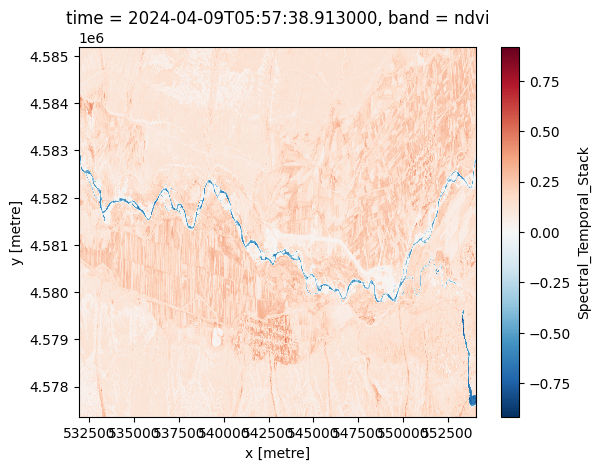

In [6]:
da_sel.sel(time="2024-04-09").plot()

## Raincloud graph design !dont delete, might need for Franken!

In [5]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
import xarray as xr
#sns.set(style="darkgrid")
#sns.set(style="whitegrid")
#sns.set_style("white")
sns.set(style="whitegrid",font_scale=2)
import matplotlib.collections as clt

In [6]:
import sys
sys.path.append('../ptitprince/')
import ptitprince as pt

In [5]:
da

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 492, band: 6, y: 1208, x: 705)> Size: 20GB
[2514041280 values with dtype=float64]
Coordinates:
  * y        (y) float64 10kB 5.018e+06 5.018e+06 ... 5.006e+06 5.006e+06
  * x        (x) float64 6kB 6.335e+05 6.335e+05 ... 6.405e+05 6.405e+05
  * time     (time) datetime64[ns] 4kB 2017-01-09T04:21:34.464000 ... 2025-01...
  * band     (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
Attributes:
    grid_mapping:  spatial_ref

**Select band**

**Select years**

In [ ]:
ds1 = xr.open_dataset("/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/extentFranken_20152017_100m.nc")
ds2 = xr.open_dataset("/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/extentFranken_20182019_100m.nc")
ds3 = xr.open_dataset("/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/results/extentFranken_20212024_100m.nc")

da1 = ds1.Spectral_Temporal_Stack
da2 = ds2.Spectral_Temporal_Stack
da3 = ds3.Spectral_Temporal_Stack

**Select band**

In [ ]:
band = 'ndvi'

da_sel1 = da1.sel(band = band)
da_sel2 = da2.sel(band = band)
da_sel3 = da3.sel(band = band)


**Select stat**

In [ ]:
stat = 'mean'

group1 = getattr(da_2017, stat)(dim=("y", "x"))
group2 = getattr(da_2018, stat)(dim=("y", "x"))
group3 = getattr(da_2019, stat)(dim=("y", "x"))
group4 = getattr(da_2020, stat)(dim=("y", "x"))
group5 = getattr(da_2021, stat)(dim=("y", "x"))
group6 = getattr(da_2022, stat)(dim=("y", "x"))
group7 = getattr(da_2023, stat)(dim=("y", "x"))
group8 = getattr(da_2024, stat)(dim=("y", "x"))
group9 = getattr(da_2025, stat)(dim=("y", "x"))

In [ ]:
series1 = pd.Series(group1.values, name='2017')
series2 = pd.Series(group2.values, name='2018')
series3 = pd.Series(group3.values, name='2019')
series4 = pd.Series(group4.values, name='2020')
series5 = pd.Series(group5.values, name='2021')
series6 = pd.Series(group6.values, name='2022')
series7 = pd.Series(group7.values, name='2023')
series8 = pd.Series(group8.values, name='2024')
series9 = pd.Series(group9.values, name='2025')

# Combine into a single DataFrame
#df = pd.concat([series1, series2, series3, series4, series5, series6, series7, series8, series9], axis=1).melt(var_name='Period', value_name='NDVI')

In [ ]:
series_list = [s.reset_index(drop=True) for s in 
               [series1, series2, series3, series4, series5, series6, series7, series8, series9]]

df = pd.concat([s.reset_index(drop=True) for s in series_list], axis=1)

# Melt the dataframe
df_melted = df.melt(var_name='Period', value_name='NDVI')

# Drop the rows with NaN values
df_melted = df_melted.dropna().reset_index(drop=True)

print(df_melted)

    Period      NDVI
0     2017  0.090793
1     2017  0.065247
2     2017  0.069136
3     2017 -0.023448
4     2017  0.082246
..     ...       ...
487   2025  0.069392
488   2025  0.056730
489   2025  0.059364
490   2025  0.063781
491   2025  0.061617

[492 rows x 2 columns]


In [15]:
polygon_folder = './polygons/'
polygon = polygon_folder + 'test_polygon.gpkg' # prepare default folder ./polygons so the user can simply enter file name+ext
daterange = ['2021-01-01', '2021-03-01'] # offer user an example then accept input
mission = 's1' #collection # offer user list of missions then accept input
#bands = ['coastal', 'blue', 'green', 'red', 'rededge1', 'rededge2', 'rededge3', 'nir', 'nir08', 'nir09',  'swir16', 'swir22'] # offer user list of bands then accept input
bands = ['vv', 'vh']
#max_cc = 10 # tell user to use int
indices = ['rvi']
output = "./results/test.nc"
# aggregator = mean or median # ask user if aggregation is wanted if yes, offer user mean or median otherwise
#topographic_features = ['slope', 'aspect', 'd_inf_flow_accumulation', 'twi']
#animation = False

if mission == 's1':
    cloud_masking = False
else:
    cloud_masking = False # login_node_run: user input

Future idea: export txt metadata file

In [16]:
from terrabyte_cube import main

In [17]:
da = main.mainfunc(mission=mission, polygon=polygon, daterange=daterange, bands=bands)

In [18]:
import planetary_computer
import pystac
import pystac_client
import json
raw_item: pystac.Item = 'st=2024-09-09T09%3A18%3A02Z&se=2024-09-10T10%3A03%3A02Z&sp=rl&sv=2024-05-04&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2024-09-10T03%3A49%3A03Z&ske=2024-09-17T03%3A49%3A03Z&sks=b&skv=2024-05-04&sig=3DTxdXufdHAJLB3kTtg0TPSB3wc2KXOVlKzF17NqmV4%3D'
item: pystac.Item = planetary_computer.sign(raw_item)

In [10]:
planetary_computer.sign(raw_item)

'st=2024-09-09T09%3A18%3A02Z&se=2024-09-10T10%3A03%3A02Z&sp=rl&sv=2024-05-04&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2024-09-10T03%3A49%3A03Z&ske=2024-09-17T03%3A49%3A03Z&sks=b&skv=2024-05-04&sig=3DTxdXufdHAJLB3kTtg0TPSB3wc2KXOVlKzF17NqmV4%3D'

In [19]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1/",
    modifier=planetary_computer.sign_inplace,
)

In [20]:
da

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 5, band: 2, y: 1001, x: 944)> Size: 38MB
dask.array<transpose, shape=(5, 2, 1001, 944), dtype=float32, chunksize=(1, 1, 1001, 944), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 8kB 5.012e+06 5.012e+06 ... 5.002e+06 5.002e+06
  * x            (x) float64 8kB 6.349e+05 6.349e+05 ... 6.443e+05 6.443e+05
  * time         (time) datetime64[ns] 40B 2021-01-02T23:24:55.259722 ... 202...
    spatial_ref  int64 8B 0
  * band         (band) <U2 16B 'vv' 'vh'

In [21]:
planetary_computer.sign_inplace

<function planetary_computer.sas.sign_inplace(obj: Any) -> Any>

In [22]:
da.compute()

Aborting load due to failure while reading: https://sentinel1euwestrtc.blob.core.windows.net/sentinel1-grd-rtc/GRD/2021/2/19/IW/DV/S1B_IW_GRDH_1SDV_20210219T232441_20210219T232506_025682_030FBE_AE7C/measurement/iw-vh.rtc.tiff:1
Aborting load due to failure while reading: https://sentinel1euwestrtc.blob.core.windows.net/sentinel1-grd-rtc/GRD/2021/2/19/IW/DV/S1B_IW_GRDH_1SDV_20210219T232441_20210219T232506_025682_030FBE_AE7C/measurement/iw-vv.rtc.tiff:1


RasterioIOError: HTTP response code: 404

In [5]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

In [6]:
data = da.sel(band='rvi')

In [7]:
data

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 23, y: 1001, x: 944)> Size: 87MB
dask.array<getitem, shape=(23, 1001, 944), dtype=float32, chunksize=(1, 1001, 944), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 8kB 5.012e+06 5.012e+06 ... 5.002e+06 5.002e+06
  * x            (x) float64 8kB 6.349e+05 6.349e+05 ... 6.443e+05 6.443e+05
  * time         (time) datetime64[ns] 184B 2021-01-02T23:24:55.259722 ... 20...
    spatial_ref  int64 8B 0
    band         <U5 20B 'rvi'

Aborting load due to failure while reading: https://sentinel1euwestrtc.blob.core.windows.net/sentinel1-grd-rtc/GRD/2021/8/18/IW/DV/S1B_IW_GRDH_1SDV_20210818T232448_20210818T232513_028307_0360A6_723F/measurement/iw-vh.rtc.tiff:1
Aborting load due to failure while reading: https://sentinel1euwestrtc.blob.core.windows.net/sentinel1-grd-rtc/GRD/2021/8/18/IW/DV/S1B_IW_GRDH_1SDV_20210818T232448_20210818T232513_028307_0360A6_723F/measurement/iw-vv.rtc.tiff:1


RasterioIOError: HTTP response code: 404

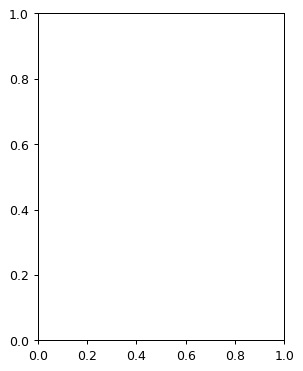

In [8]:
y_dim = data.sizes['y']
x_dim = data.sizes['x']
aspect_ratio = y_dim / x_dim

# Define base figure size and scale by aspect ratio
base_width = 10
base_height = 5
fig_width = base_width * min(1.5, max(0.5, aspect_ratio))  # limit within 0.5 and 1.5
fig_height = base_height * min(1.5, max(0.5, 1 / aspect_ratio))  # inverse ratio for height


fig = plt.figure(figsize=(fig_width, fig_height), dpi=90)
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 3], wspace=0.4)  # Adjust wspace to add horizontal spacing

# Plot the mean image
ax0 = plt.subplot(gs[0])
data.mean(dim="time").plot.imshow(vmin=0, vmax=1, ax=ax0)
ax0.set_title("Mean RVI")
ax0.tick_params(axis="x", rotation=45)



# Plot the timeseries
ax1 = plt.subplot(gs[1])
ax1.plot(data.time.to_numpy(), data.mean(dim=("x", "y")).to_numpy())
ax1.set_title("RVI Timeseries")
ax1.set_xlabel("Time")
ax1.set_ylabel("Pixel Values")
ax1.tick_params(axis="x", rotation=45)

# Adjust spacing around the entire figure and between subplots
fig.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1, wspace=0.4)
plt.show()

copernicus

### COG Export

In [17]:
from datacube.utils.cog import write_cog #odc-tools

In [20]:
data_stacked = da
output_dir = './results/cogs/'
for i in range(len(data_stacked.time)):

    # We will use the date of the satellite image to name the GeoTIFF
    date = data_stacked.isel(time=i).time.dt.strftime('%Y-%m-%d').data
    print(f'Writing {date}')

    # Convert current time step into a `xarray.DataArray`
    singleTimestamp = data_stacked.isel(time=i)

    output_file = f'{output_dir}{date}.tif'
    
    # Write GeoTIFF
    write_cog(singleTimestamp,
              fname=output_file,
              overwrite=True)

Writing 2021-03-01
Writing 2021-03-06
Writing 2021-04-10
Writing 2021-04-25
Writing 2021-04-28
Writing 2021-05-03


## Planetary Computer test

In [2]:
!pip install planetary-computer

Defaulting to user installation because normal site-packages is not writeable
  Using cached planetary_computer-1.0.0-py3-none-any.whl (14 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.9/434.9 kB 1.6 MB/s eta 0:00:0000:01
  Using cached python_dotenv-1.0.1-py3-none-any.whl (19 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl (13 kB)
  Using cached typing_extensions-4.12.2-py3-none-any.whl (37 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 10.1 MB/s eta 0:00:00:00:01


In [1]:
import planetary_computer
import pystac_client
import pystac
from odc.stac import stac_load
from pystac_client import Client as pystacclient

In [16]:
raw_item: pystac.Item = "st=2024-09-09T09%3A18%3A02Z&se=2024-09-10T10%3A03%3A02Z&sp=rl&sv=2024-05-04&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2024-09-10T03%3A49%3A03Z&ske=2024-09-17T03%3A49%3A03Z&sks=b&skv=2024-05-04&sig=3DTxdXufdHAJLB3kTtg0TPSB3wc2KXOVlKzF17NqmV4%3D"
item: pystac.Item = planetary_computer.sign(raw_item)

In [2]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace
)

In [3]:
catalog

<Client id=microsoft-pc>